Matches found: 49


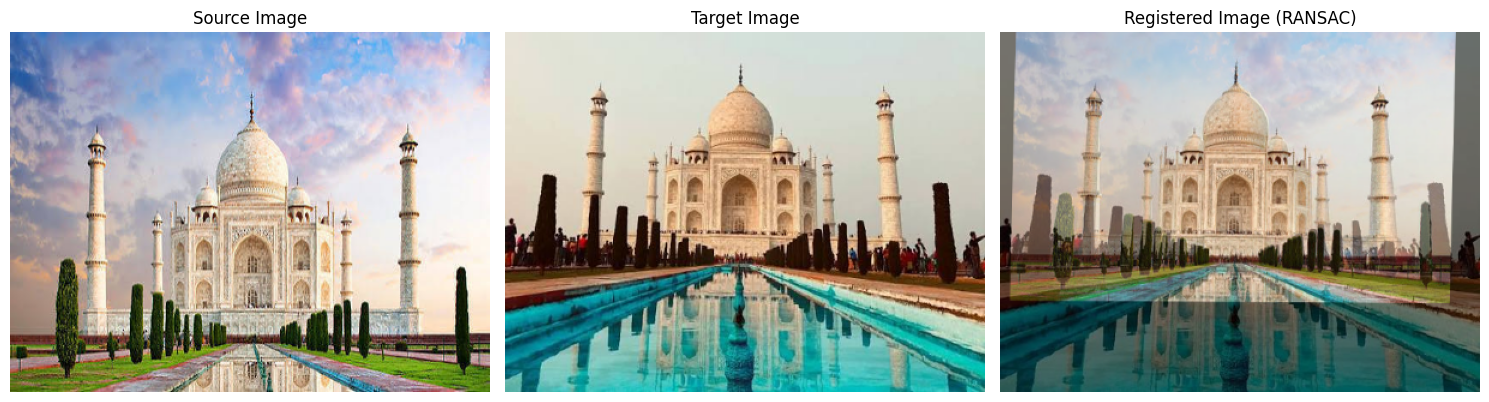

In [1]:
import cv2
import numpy as np

# -------------------------
# Affine Transformation
# -------------------------

def estimate_affine(s, t):
    num = s.shape[1]

    M = np.zeros((2 * num, 6))

    for i in range(num):
        temp = [
            [s[0, i], s[1, i], 0, 0, 1, 0],
            [0, 0, s[0, i], s[1, i], 0, 1]
        ]
        M[2 * i:2 * i + 2, :] = np.array(temp)

    b = t.T.reshape((2 * num, 1))

    theta = np.linalg.lstsq(M, b, rcond=None)[0]

    X = theta[:4].reshape((2, 2))
    Y = theta[4:]

    return X, Y


# -------------------------
# RANSAC
# -------------------------

K = 3
THRESHOLD = 1
ITER_NUM = 2000


def residual_lengths(X, Y, s, t):
    e = np.dot(X, s) + Y
    diff_square = np.power(e - t, 2)
    residual = np.sqrt(np.sum(diff_square, axis=0))
    return residual


def ransac_fit(pts_s, pts_t):
    inliers_num = 0
    A = None
    t = None
    inliers = None

    for _ in range(ITER_NUM):

        idx = np.random.randint(0, pts_s.shape[1], K)

        A_tmp, t_tmp = estimate_affine(
            pts_s[:, idx],
            pts_t[:, idx]
        )

        residual = residual_lengths(
            A_tmp,
            t_tmp,
            pts_s,
            pts_t
        )

        inliers_tmp = np.where(residual < THRESHOLD)
        inliers_num_tmp = len(inliers_tmp[0])

        if inliers_num_tmp > inliers_num:
            inliers_num = inliers_num_tmp
            inliers = inliers_tmp
            A = A_tmp
            t = t_tmp

    return A, t, inliers


# -------------------------
# SIFT Feature Extraction
# -------------------------

def extract_SIFT(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp, desc = sift.detectAndCompute(gray, None)

    kp = np.array([p.pt for p in kp]).T

    return kp, desc


# -------------------------
# Feature Matching
# -------------------------

def match_SIFT(descriptor_source, descriptor_target):
    bf = cv2.BFMatcher()

    matches = bf.knnMatch(
        descriptor_source,
        descriptor_target,
        k=2
    )

    pos = np.empty((0, 2), dtype=np.int32)

    for m, n in matches:
        if m.distance < 0.8 * n.distance:
            pos = np.vstack(
                (pos, [m.queryIdx, m.trainIdx])
            )

    return pos


# -------------------------
# Affine Matrix Estimation
# -------------------------

def affine_matrix(s, t, pos):

    s = s[:, pos[:, 0]]
    t = t[:, pos[:, 1]]

    _, _, inliers = ransac_fit(s, t)

    s = s[:, inliers[0]]
    t = t[:, inliers[0]]

    A, trans = estimate_affine(s, t)

    M = np.hstack((A, trans))

    return M


# -------------------------
# Main Program
# -------------------------

img_source = cv2.imread(
    r"C:\Users\marun\Downloads\taj1.jpg"
)

img_target = cv2.imread(
    r"C:\Users\marun\Downloads\taj2.jpg"
)

if img_source is None:
    print("Source image not found!")
    exit()

if img_target is None:
    print("Target image not found!")
    exit()

kp_source, desc_source = extract_SIFT(img_source)
kp_target, desc_target = extract_SIFT(img_target)

pos = match_SIFT(desc_source, desc_target)

print("Matches found:", len(pos))

H = affine_matrix(
    kp_source,
    kp_target,
    pos
)

rows, cols = img_target.shape[:2]

warp = cv2.warpAffine(
    img_source,
    H,
    (cols, rows)
)

merge = cv2.addWeighted(
    img_target,
    0.5,
    warp,
    0.5,
    0
)



# Resize all images to same size
img_source_r = cv2.resize(img_source, (400, 300))
img_target_r = cv2.resize(img_target, (400, 300))
merge_r = cv2.resize(merge, (400, 300))

# Combine side by side
result = np.hstack((img_source_r, img_target_r, merge_r))
import matplotlib.pyplot as plt

# Resize all images to same size
img_source_r = cv2.resize(img_source, (400, 300))
img_target_r = cv2.resize(img_target, (400, 300))
merge_r = cv2.resize(merge, (400, 300))

# Convert BGR to RGB
img_source_r = cv2.cvtColor(img_source_r, cv2.COLOR_BGR2RGB)
img_target_r = cv2.cvtColor(img_target_r, cv2.COLOR_BGR2RGB)
merge_r = cv2.cvtColor(merge_r, cv2.COLOR_BGR2RGB)

# Display all three images in one row
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_source_r)
plt.title("Source Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_target_r)
plt.title("Target Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(merge_r)
plt.title("Registered Image (RANSAC)")
plt.axis("off")

plt.tight_layout()
plt.show()